<img src="./logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0
#### Yugra Yoseli
### 1er Cuatrimestre 2026

# Consigna
En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primera tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

la amplitud máxima de la senoidal (voltios)
su valor medio (voltios)
la frecuencia (Hz)
la fase (radianes)
la cantidad de muestras digitalizadas por el ADC (# muestras)
la frecuencia de muestreo del ADC.
es decir que la función que uds armen debería admitir se llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs) Recuerden que tanto xx como tt deben ser vectores de Nx1. Puede resultarte útil el módulo de visualización matplotlib.pyplot donde encontrarás todas las funciones de visualización estilo Matlab. Para usarlo:

import matplotlib.pyplot as plt

plt.plot(tt, xx)

Entrega
Recuerden que solo tienen que entregar una URL a su cuaderno. Con esa URL ya tendrás acceso a su repositorio y todo lo que usaron.

https://nbviewer.jupyter.org/github/marianux/PDS/blob/main/preparacion.ipynb

Bonus:
💎 Ser el primero en subir un enlace a tu cuaderno en esta tarea

Realizar los experimentos que se comentaron en clase. Siguiendo la notación de la función definida más arriba:

ff = 500 Hz ff = 999 Hz ff = 1001 Hz ff = 2001 Hz

🤯 Implementar alguna otra señal propia de un generador de señales. Ayudas:

La función numpy.sin seguro te va a servir.
No hace falta usar ningún lazo de control for, while, etc.
Podés consultar en el chat cualquier duda o problema que vayas encontrando. ¡Buena suerte!

# Introducción

    El objetivo de este trabajo es poder representar una señal en forma digital, utilizando una cantidad determinada de muestras y una frecuencia de muestreo. Este tipo de señales es fundamental en el procesamiento digital de señales. 
    En este trabajo se implementa una función capaz de generar señales senoideales discretas a partir de distintos parámetros, como amplitud, frecuencia y valor medio, la forma gneral para una señal senoideal es:

    
x ( t ) = A . sen ( 2 π​​Ft + ϕ ) + D C
 

donde:

vmax
   →
 amplitud máxima (A)

ff
   →
 frecuencia (Hz)

t
   →
 tiempo

ph
   →
 fase inicial (ϕ)

D C
   →
 valor medio (offset)

In [1]:
#%% DEFENICION DE LA FUNCIÓN
import matplotlib.pyplot as plt
import numpy as np

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs
    tt = np.arange(nn) * ts          # vector de tiempo Nx1
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx



## Bonus

Se mostraran los distintas frencuencias y sus respectivos graficos


In [2]:
#%%BONUS
N  = 1000
fs = 1000

# ff = 500 Hz  →  justo en Nyquist (fs/2)
t1, x1 = mi_funcion_sen(vmax=1, dc=0, ff=500,  ph=0, nn=N, fs=fs)

# ff = 999 Hz
t2, x2 = mi_funcion_sen(vmax=1, dc=0, ff=999,  ph=0, nn=N, fs=fs)

# ff = 1001 Hz  →  alias de 999 Hz
t3, x3 = mi_funcion_sen(vmax=1, dc=0, ff=1001, ph=0, nn=N, fs=fs)

# ff = 2001 Hz  →  alias de 1 Hz
t4, x4 = mi_funcion_sen(vmax=1, dc=0, ff=2001, ph=0, nn=N, fs=fs)


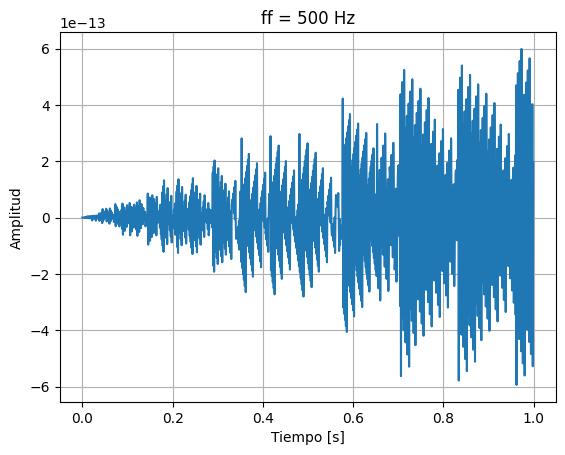

In [3]:
#%%VISUALIZACIÓN DE LOS 4 CASOS 
# Plot 1 — ff = 500 Hz
plt.figure()
plt.plot(t1, x1)
plt.title("ff = 500 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

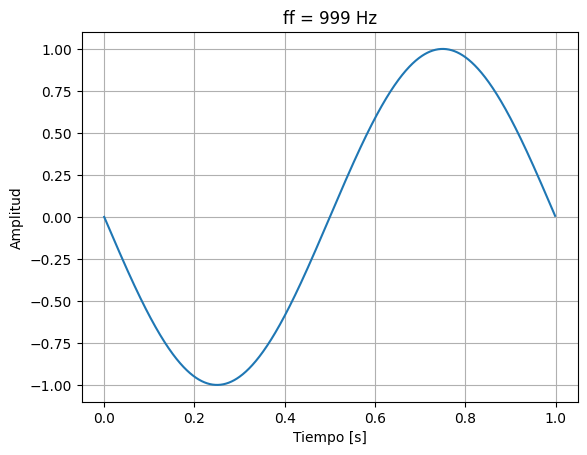

In [4]:
# Plot 2 — ff = 999 Hz
plt.figure()
plt.plot(t2, x2)
plt.title("ff = 999 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

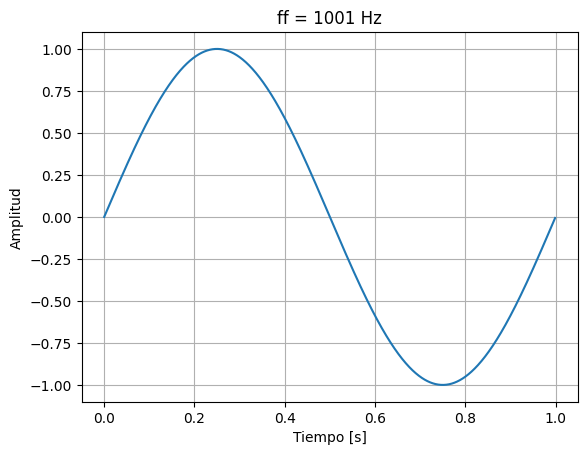

In [5]:
# Plot 3 — ff = 1001 Hz  (alias de 999 Hz)
plt.figure()
plt.plot(t3, x3)
plt.title("ff = 1001 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

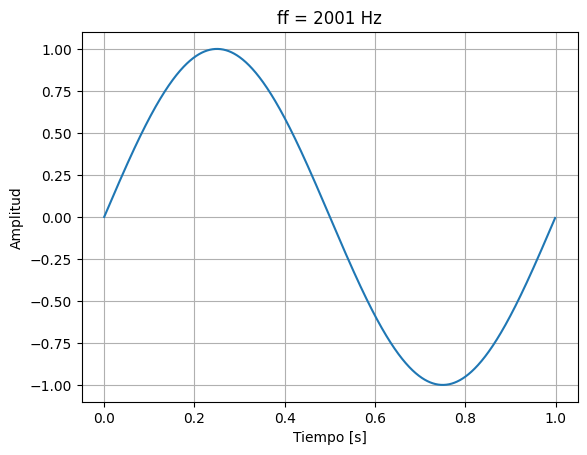

In [6]:
# Plot 4 — ff = 2001 Hz  (alias de 1 Hz)
plt.figure()
plt.plot(t4, x4)
plt.title("ff = 2001 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


Cuando se muestrea una señal, las frecuencias que difieren en múltiplos de la frecuencia de muestreo no pueden distinguirse.

En este caso, con fs = 1000 Hz:

- 2001 Hz → 2001 - 2·1000 = 1 Hz

Por lo tanto, una señal de 2001 Hz se observa como una señal de 1 Hz en tiempo discreto.

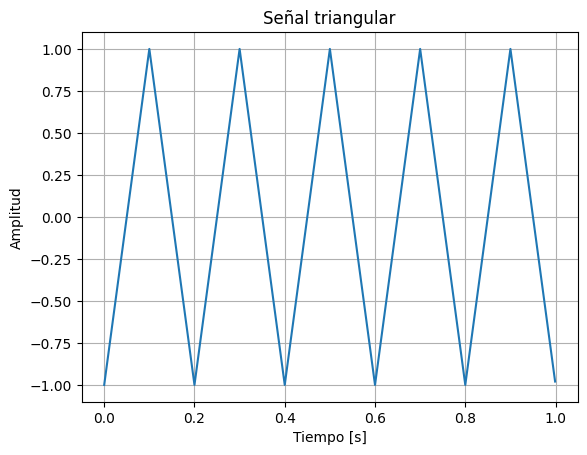

In [7]:
#%%UNA SEÑAL TRIANGULAR
from scipy import signal as sig

def mi_funcion_triangular(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs
    tt = np.arange(nn) * ts
    xx = dc + vmax * sig.sawtooth(2 * np.pi * ff * tt + ph, width=0.5)
    return tt, xx

t5, x5 = mi_funcion_triangular(vmax=1, dc=0, ff=5, ph=0, nn=N, fs=fs)
plt.figure()
plt.plot(t5, x5)
plt.title("Señal triangular")
plt.xlabel("Tiempo [s]"), plt.ylabel("Amplitud"), plt.grid(True)
plt.show()


A diferencia de la senoidal, la señal triangular no es una frecuencia pura.
Está formada por la frecuencia fundamental más armónicos impares 
cuyas amplitudes decaen rápidamente. Por eso su forma es lineal a tramos
y no suave como la senoidal.

## Conclusión

A partir de los gráficos obtenidos, se observa que la señal de 500 Hz muestra un comportamiento distinto al resto, ya que se encuentra en el límite de Nyquist (fs/2), generando una señal con apariencia más irregular debido a la submuestreo en ese punto crítico.

Por otro lado, las señales de 999 Hz, 1001 Hz y 2001 Hz resultan prácticamente indistinguibles entre sí en tiempo discreto, presentando una forma senoidal de baja frecuencia.

Esto se debe al fenómeno de aliasing, donde frecuencias que son simétricas respecto de la frecuencia de muestreo o que difieren en múltiplos de la misma se representan de forma equivalente luego del muestreo.

En particular:
- 999 Hz = fs − 1  
- 1001 Hz = fs + 1  
- 2001 Hz = 2·fs + 1  

Todas estas frecuencias producen una frecuencia alias de aproximadamente 1 Hz, lo que explica que sus representaciones discretas coincidan.

Se concluye que, aunque estas frecuencias son diferentes en el dominio continuo, el proceso de muestreo no permite distinguirlas, evidenciando la pérdida de información que introduce el aliasing.